In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)


In [4]:



file_path = "/content/healthcare_dataset.csv.xls"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset Shape: (55500, 15)

Columns:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


In [5]:

df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'], errors='coerce'
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'], errors='coerce'
)


df['Billing Amount'] = pd.to_numeric(
    df['Billing Amount'], errors='coerce'
)

df['Stay Duration'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

df = df[df['Stay Duration'] >= 0]


df = df.dropna(
    subset=[
        'Medical Condition',
        'Insurance Provider',
        'Billing Amount',
        'Date of Admission'
    ]
)

print("\nCleaned Dataset Shape:", df.shape)


Cleaned Dataset Shape: (55500, 16)


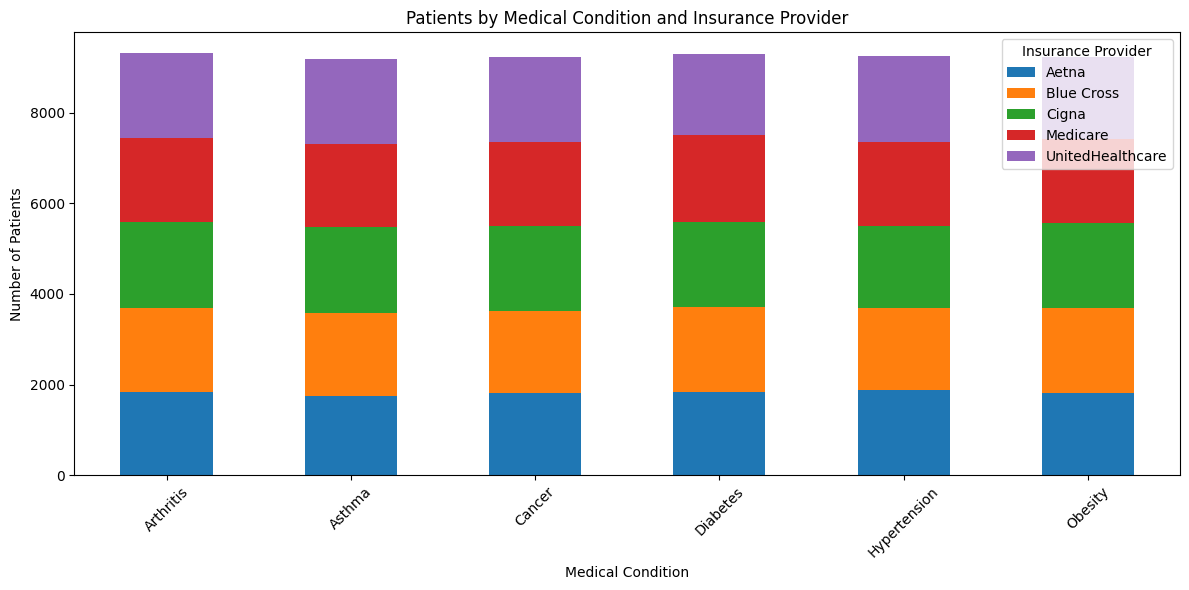

In [6]:
condition_insurance = pd.crosstab(
    df['Medical Condition'],
    df['Insurance Provider']
)

condition_insurance.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Patients by Medical Condition and Insurance Provider')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Insurance Provider')
plt.tight_layout()
plt.show()


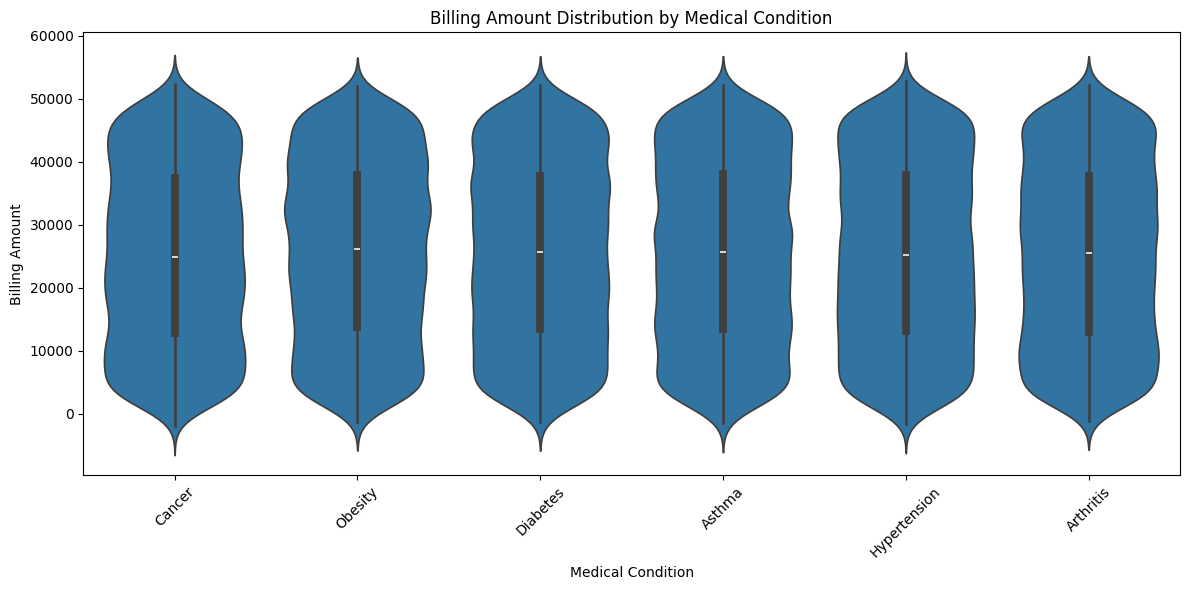

In [7]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount'
)

plt.title('Billing Amount Distribution by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


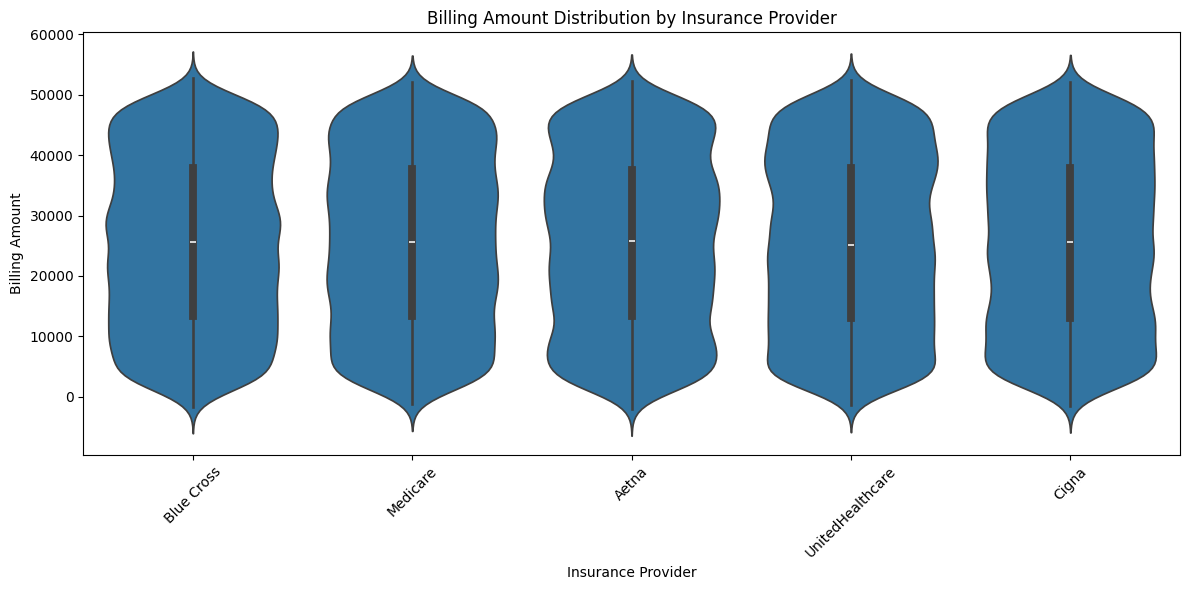

In [8]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='Insurance Provider',
    y='Billing Amount'
)

plt.title('Billing Amount Distribution by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3824/2146689596.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


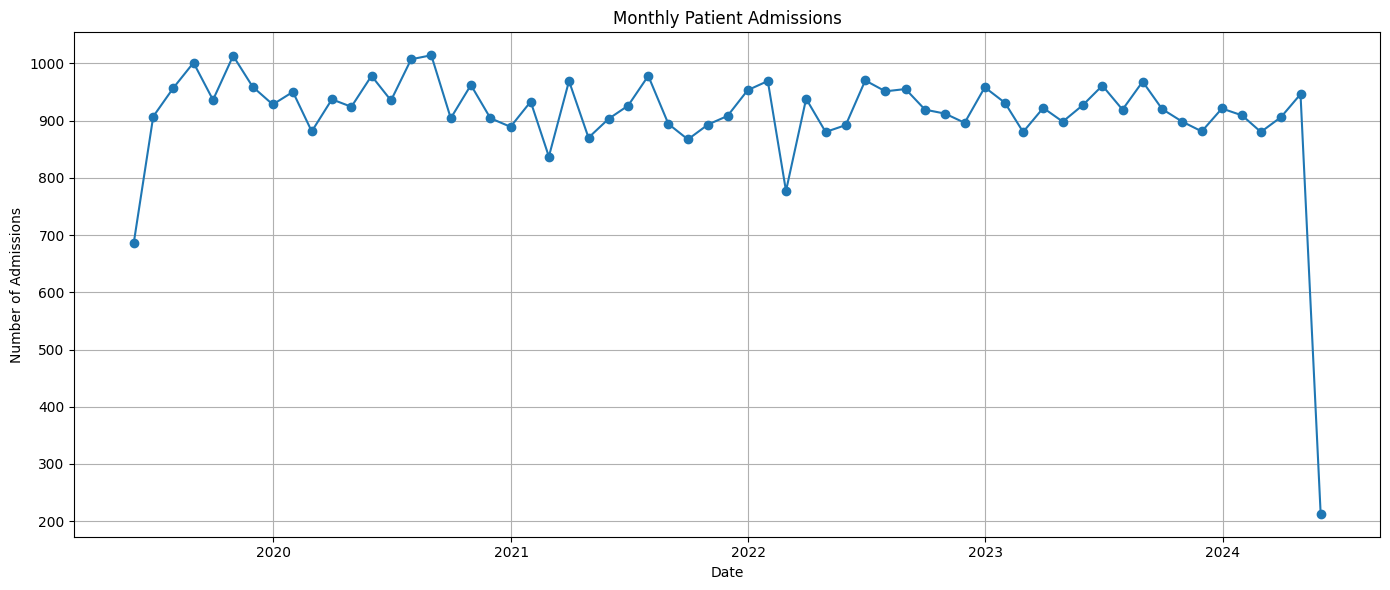

In [9]:
monthly_admissions = (
    df.set_index('Date of Admission')
      .resample('M')
      .size()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    marker='o'
)

plt.title('Monthly Patient Admissions')
plt.xlabel('Date')
plt.ylabel('Number of Admissions')
plt.grid(True)
plt.tight_layout()
plt.show()

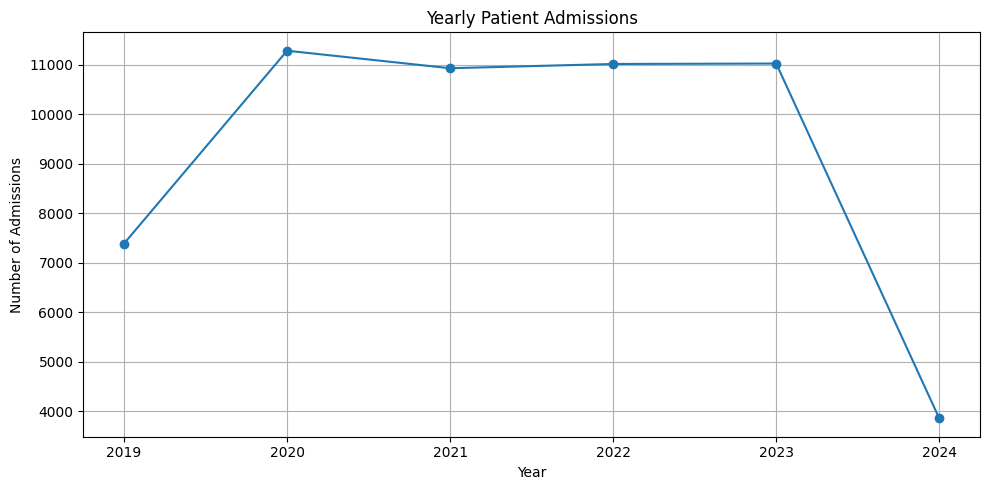

In [10]:
yearly_admissions = (
    df['Date of Admission']
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_admissions.index,
    yearly_admissions.values,
    marker='o'
)

plt.title('Yearly Patient Admissions')
plt.xlabel('Year')
plt.ylabel('Number of Admissions')
plt.grid(True)
plt.tight_layout()
plt.show()


Correlation Matrix:
                     Age  Stay Duration  Billing Amount
Age             1.000000       0.008220       -0.003832
Stay Duration   0.008220       1.000000       -0.005602
Billing Amount -0.003832      -0.005602        1.000000


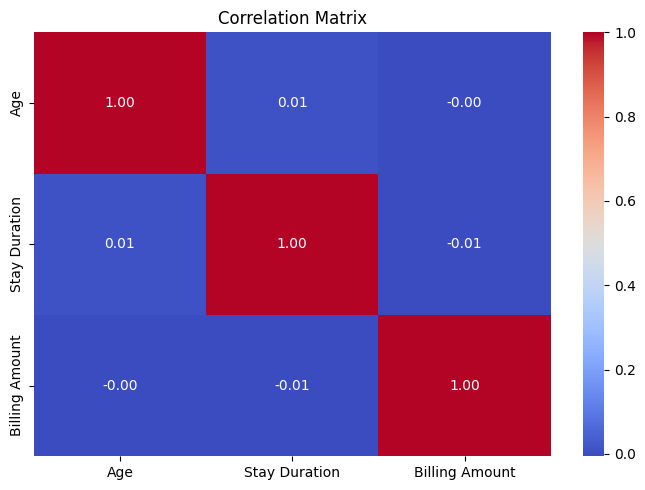

In [11]:
correlation_data = df[
    ['Age', 'Stay Duration', 'Billing Amount']
]

correlation_matrix = correlation_data.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(7,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [12]:
print("\nBilling Amount Statistics:")
print(df['Billing Amount'].describe())

print("\nStay Duration Statistics:")
print(df['Stay Duration'].describe())

print("\nAge Statistics:")
print(df['Age'].describe())



Billing Amount Statistics:
count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64

Stay Duration Statistics:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Stay Duration, dtype: float64

Age Statistics:
count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64


In [13]:
condition_cost = (
    df.groupby('Medical Condition')['Billing Amount']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
)

print("\nBilling Summary by Medical Condition:")
print(condition_cost)


Billing Summary by Medical Condition:
                           mean        median  count
Medical Condition                                   
Obesity            25805.971259  26129.997134   9231
Diabetes           25638.405577  25621.077269   9304
Asthma             25635.249359  25661.872824   9185
Arthritis          25497.327056  25581.763549   9308
Hypertension       25497.095761  25275.670593   9245
Cancer             25161.792707  24910.980640   9227


In [14]:
insurance_cost = (
    df.groupby('Insurance Provider')['Billing Amount']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
)

print("\nBilling Summary by Insurance Provider:")
print(insurance_cost)


Billing Summary by Insurance Provider:
                            mean        median  count
Insurance Provider                                   
Medicare            25615.990508  25592.810719  11154
Blue Cross          25613.011503  25594.699731  11059
Aetna               25553.294506  25786.388779  10913
Cigna               25525.766314  25545.200901  11249
UnitedHealthcare    25389.172390  25185.491443  11125


In [15]:
stay_summary = (
    df.groupby('Medical Condition')['Stay Duration']
      .agg(['mean', 'median'])
      .sort_values('mean', ascending=False)
)

print("\nStay Duration by Medical Condition:")
print(stay_summary)



Stay Duration by Medical Condition:
                        mean  median
Medical Condition                   
Asthma             15.696570    16.0
Arthritis          15.517404    15.0
Cancer             15.495827    15.0
Obesity            15.464305    15.0
Hypertension       15.458626    15.0
Diabetes           15.422936    15.0


In [16]:
correlation = correlation_data.corr()

print(correlation)

                     Age  Stay Duration  Billing Amount
Age             1.000000       0.008220       -0.003832
Stay Duration   0.008220       1.000000       -0.005602
Billing Amount -0.003832      -0.005602        1.000000


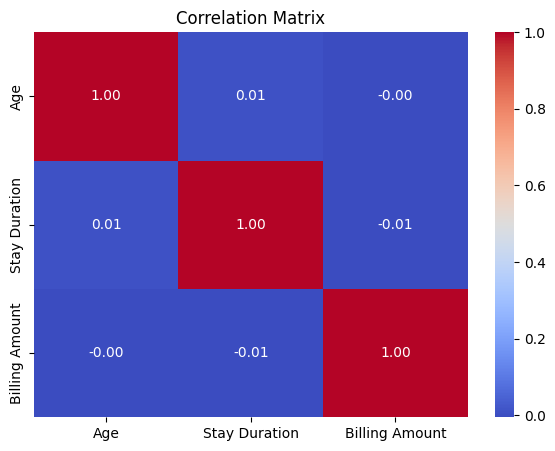

In [17]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [18]:
print(df['Billing Amount'].describe())

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64


In [19]:
condition_cost = df.groupby(
    'Medical Condition'
)['Billing Amount'].mean()

print(condition_cost)

Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64


In [20]:
insurance_cost = df.groupby(
    'Insurance Provider'
)['Billing Amount'].mean()

print(insurance_cost)

Insurance Provider
Aetna               25553.294506
Blue Cross          25613.011503
Cigna               25525.766314
Medicare            25615.990508
UnitedHealthcare    25389.172390
Name: Billing Amount, dtype: float64


In [21]:
stay = df.groupby(
    'Medical Condition'
)['Stay Duration'].mean()

print(stay)

Medical Condition
Arthritis       15.517404
Asthma          15.696570
Cancer          15.495827
Diabetes        15.422936
Hypertension    15.458626
Obesity         15.464305
Name: Stay Duration, dtype: float64


In [22]:
print("EXECUTIVE SUMMARY")
print("------------------")

print("Total Patients:", len(df))

print(
    "Average Billing Amount:",
    round(df['Billing Amount'].mean(), 2)
)

print(
    "Average Stay Duration:",
    round(df['Stay Duration'].mean(), 2),
    "days"
)

print(
    "Average Patient Age:",
    round(df['Age'].mean(), 2)
)

EXECUTIVE SUMMARY
------------------
Total Patients: 55500
Average Billing Amount: 25539.32
Average Stay Duration: 15.51 days
Average Patient Age: 51.54


In [23]:
print("\nHEALTHCARE MANAGEMENT RECOMMENDATIONS")
print("--------------------------------------")

print("1. Monitor high-cost medical conditions.")
print("2. Analyze insurance-wise billing patterns.")
print("3. Prepare resources during admission surges.")
print("4. Monitor patients with long hospital stays.")
print("5. Use admission trends for staff planning.")
print("6. Use billing analysis for better budget planning.")


HEALTHCARE MANAGEMENT RECOMMENDATIONS
--------------------------------------
1. Monitor high-cost medical conditions.
2. Analyze insurance-wise billing patterns.
3. Prepare resources during admission surges.
4. Monitor patients with long hospital stays.
5. Use admission trends for staff planning.
6. Use billing analysis for better budget planning.
